![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)



# Tutorial to access the impact-sector application output of  HydroMet

**Author**: EUMETSAT <br>
**Copyright**: 2024 EUMETSAT <br>
**Licence**: MIT <br>
**Modified by**: chartick

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b>
<li> For Data access : <a href="https://platform.destine.eu/"> DestinE user account and access to restricted datasets</a> </li>
<li> Installation of Python packages <code class="python">destinelab tqdm xarray geopandas netCDF4 matplotlib</code></li>
<li> The described dataset will be available at the end of July.</a> </li>
</div>

This notebook demonstrates searching for and downloading the HydroMet application output from the Destination Earth Data Lake.

### Import the relevant modules

Data from the impact-sector applications can be accessed via the Data Lake using simple HTTP requests with the Python package `requests`.

However, the requests need to be authenticated with the package `destinelab`. `json` is needed to handle JSON files retrieved in the search process, while `tqdm` provides a simple progress bar, `getpass` is used to safely parse passwords and `xarray` is used to visualise the retrieved data. 

In [1]:
import requests
import destinelab as deauth
import json
from getpass import getpass
from tqdm import tqdm
import xarray as xr
import geopandas



### Define some constants for the API URL

In this section, we define some access points. The `COLLECTION_ID` in the first cell is a unique identifier, in our case, for the HydroMet collection. The second cell contains URLs that are the same across all collections. 

The `STAC_API` is the central point for discovering data under the STAC standard on the Destination Earth Data Lake. The data is served through different collections with their own address specified here with the `COLLECTION_BY_ID_URL`. Lastly, the `SEARCH_URL` is used to query searches through the Data Lake. 


In [2]:
# Define the collection to be used
COLLECTION_ID = "EO.DWD.STAT.HYDROMET_EXTREMES"

In [3]:
# STAC API
STAC_API_URL = "https://hda.data.destination-earth.eu/stac/v2"

## Collections
COLLECTION_BY_ID_URL = f"{STAC_API_URL}/collections/{COLLECTION_ID}"

## Item Search
SEARCH_URL = f"{STAC_API_URL}/search"

## Authenticate

Some collections can be accessed by everyone, but impact-sector output is restricted. Therefore, we obtain an authorisation header in the following cell by inputting our username and password.

In [ ]:
DESP_USERNAME = input("Please input your DestinE Service Platform username or email: ")
DESP_PASSWORD = getpass("Please input your DestinE Service Platform password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("Access Token Obtained Successfully")
else:
    print("Failed to Obtain Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

### Discover data - Authenticated

Once authenticated, we can discover the collection by triggering a request. If successful, the collection description is displayed in JSON format. The content is identical to that available via the graphical interface at https://data.destination-earth.eu/data-portfolio and provides an overview of the collection.

Here, it is important to understand the hierarchy of an STAC collection.
1. Collection
2. Items
3. Assets (actual files)

First, we discover the collection that does not contain data files. Instead, it defines the context for all items belonging to it. The items then describe one spatiotemporal observation, or in our case, a model result. They can have multiple files associated with them and can be accessed as a whole or on a singular asset (file) basis.

In [ ]:
response = requests.get(COLLECTION_BY_ID_URL, headers=auth_headers)

print(json.dumps(response.json(), indent=4))

## Search

In the next step, we want to look at the items in a collection. As mentioned before, items are part of a collection and describe a spatiotemporal observation or snapshot, subject to flexible rules.

HydroMet's items are grouped by the underlying climate model (ICON, IFS-FEOSM, IFS-NEMO) and the activity (baseline historical period or projection). The following widget helps us select one item.

In [6]:
import ipywidgets as widgets
from IPython.display import display

# Define available options
models = ["ICON", "IFS-FESOM", "IFS-NEMO"]
activity = ["projections", "baseline"]

model_widget = widgets.Dropdown(
    options=models,
    value="ICON",
    description="Model:",
)

activity_widget = widgets.Dropdown(
    options=activity,
    value="baseline",
    description="Activity:",
)

display(model_widget, activity_widget)

def get_selection():
    return {
        "model": model_widget.value,
        "activity": activity_widget.value
    }

output = widgets.Output()

def update_output(change):
    with output:
        output.clear_output()
        selection = get_selection()
        print(f"Selected model: {selection['model']}")
        print(f"Selected activity: {selection['activity']}")

model_widget.observe(update_output, names="value")
activity_widget.observe(update_output, names="value")

display(output)

Dropdown(description='Model:', options=('ICON', 'IFS-FESOM', 'IFS-NEMO'), value='ICON')

Dropdown(description='Activity:', index=1, options=('projections', 'baseline'), value='baseline')

Output()

Using the selected model and activity, we now search the collection for items with an HTTP request in the cell below.

It is always possible to limit the search for a date range ("datetime") and a lat/lon bounding box (bbox). Furthermore, the user can specify how results are sorted and how many entries are displayed at maximum.

Additional parameters, such as the mentioned model or activity, have to be included in the "query" part of the search request. These are individual for every collection. The impact-sector applications of Climate DT have the following 

- activity": "projections" or "baseline"
- experiment": "hist" or"ssp3-7.0"
- generation": 2,
- model "IFS-NEMO", "IFS-FESOM" or "ICON"
- realisation": 1,
- resolution": "5km"
corresponding to the matching Climate DT experiment.

The search output is provided as a JSON file containing links that can be used to download specific files and entire items directly. In the latter case, all files of an item are bundled in a zip archive.

The JSON can also be converted to a more readable dataframe with the `geopandas` package.
                



In [ ]:
selected_model = model_widget.value
selected_activity = activity_widget.value

COLLECTION_ID = "EO.DWD.STAT.HYDROMET_EXTREMES"
BODY = {
    "collections": [
        COLLECTION_ID,
    ],
    "datetime": "1989-01-01T00:00:00Z/2050-12-31T00:00:00Z",
    "bbox": [-180, -90, 180, 90],
    "sortby": [{"field": "datetime", "direction": "desc"}],
    "limit": 100,
    "query":{
        "internal_fdp:activity": {
            "eq": selected_activity
       },
        "internal_fdp:model": {
            "eq": selected_model
       }
    }
}

r = requests.post(SEARCH_URL, json=BODY, headers=auth_headers)
r2 = requests.post(SEARCH_URL, json=BODY, headers=auth_headers)
if r.status_code != 200:
    (print(r.text))
r.raise_for_status()

print(json.dumps(r.json(), indent=4))

df = geopandas.GeoDataFrame.from_features(r.json()['features'], crs="epsg:4326")
df.head()

## Download

In addition to a direct download via the browser, it is also possible to automate the download with Python. 

The following code demonstrates how to download the first item from the previous search.

Warning: depending on the size of the item, the download size can be considerable!

In [8]:
# select the first item in the result to download
product = r.json()["features"][0]

# DownloadLink is an asset representing the whole product
download_url = product["assets"]["downloadLink"]["href"]
print("Download URL:", download_url)

ITEM_ID = product["id"]
print("Item ID:", ITEM_ID)

response = requests.get(download_url, stream=True, headers=auth_headers)

total_size = int(response.headers.get("Content-Length", 0))


# If the request was successful, download the file
if response.status_code == 200:

    print("Downloading ...")
    filename = ITEM_ID + ".zip"

    # Show progress bar if size is known
    with open(filename, "wb") as f, tqdm(
        total=total_size, unit="B", unit_scale=True, desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                f.flush()
                progress_bar.update(len(chunk))  # Update progress bar

else:
    print("Request Unsuccessful! Error-Code: {}".format(response.status_code))



Download URL: https://hda-download.leonardo.data.destination-earth.eu/data/internal_fdp/EO.DWD.STAT.HYDROMET_EXTREMES/EO.DWD.STAT.HYDROMET_EXTREMES_19900101T000000_20141231T230000__ICON__hist__2__1__baseline__5km/downloadLink
Item ID: EO.DWD.STAT.HYDROMET_EXTREMES_19900101T000000_20141231T230000__ICON__hist__2__1__baseline__5km


Downloading: 8.56GB [06:06, 23.4MB/s]


## Download a single file with Python

The same can be done for a single file. In the example below, we extract a specific file from the HydroMet collection to plot its content in a second step.

In [9]:
url = next(
    asset["href"]
    for feature in r2.json()["features"]
    for asset in feature.get("assets", {}).values()
    if asset.get("title", "").endswith("DDF.nc")
)


print(url)

local_file = "file.nc"

response = requests.get(url, stream=True, headers=auth_headers)

# download
with requests.get(url, stream=True) as r:
    #r.raise_for_status()
    with open(local_file, "wb") as f, tqdm(
        total=total_size, unit="B", unit_scale=True, desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                f.flush()
                progress_bar.update(len(chunk))  # Update progress bar




https://hda-download.leonardo.data.destination-earth.eu/data/internal_fdp/EO.DWD.STAT.HYDROMET_EXTREMES/EO.DWD.STAT.HYDROMET_EXTREMES_19900101T000000_20141231T230000__ICON__hist__2__1__baseline__5km/1990_01_01_T00_00_to_2014_01_01_T00_00_DDF.nc


Downloading: 1.28GB [00:12, 103MB/s] 


# Display the downloaded file

The downloaded file can be directly visualised with xarray.

The code below will visualise the strength (in mm of precipitation) of extreme precipitation events with a 100-year return period and a duration of 180 minutes from the selected model and activity in the widget above.

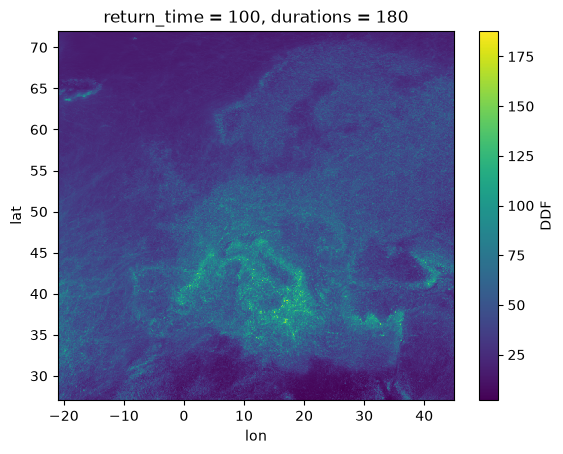

In [10]:
ds = xr.open_dataset(local_file)

return_year = 100
duration = 180

ds = ds.DDF.sel(return_time = return_year, durations = duration)
ds.plot()